# Pokemon Type Prediction using CNN

## CS 450 Project 2 -- Cameron Rich and Zach Buhai

## Data and Summary

- **Dataset**: Pokemon Images - First Generation (17000 files)
- **Source**: [Kaggle dataset by Mikołaj Kolman](https://www.kaggle.com/datasets/mikoajkolman/pokemon-images-first-generation17000-files)


This project is derived from our previous work, but we retrofitted the idea to be more neural network focused. Essentially, "can a neural network look at an image and guess what Pokémon type it is".

## Specs

- **Problem Type**: Multi-label image classification
- **Architecture**: CNN with 4 convolutional layers, max pooling, dropout regularization, and dense layers

## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    classification_report,
    multilabel_confusion_matrix,
)
import seaborn as sns

import warnings
import datetime
import glob
import random

warnings.filterwarnings("ignore", category=UserWarning, module="PIL.Image")

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = (128, 128)  # Resize to this
BATCH_SIZE = 32
EPOCHS = 20
DATA_DIR = "data"
METADATA_FILE = "metadata.csv"
OUTPUT_DIR = "output"
MIN_IMAGES_PER_CLASS = 1000
MAX_IMAGES_PER_CLASS = 2000

## Data Loading/Prep

In [2]:
def create_output_dir(output_dir=None):
    if output_dir is None:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        output_dir = os.path.join(OUTPUT_DIR, f"run_{timestamp}")

    os.makedirs(output_dir, exist_ok=True)
    print(f"All outputs will be saved to: {output_dir}")
    return output_dir

output_dir = create_output_dir()

def load_metadata():
    metadata = pd.read_csv(METADATA_FILE)
    print(f"Total Pokemon: {len(metadata)}")
    return metadata

metadata = load_metadata()
metadata.head()

All outputs will be saved to: output/run_20250502_004254
Total Pokemon: 151


,Name,Type1,Type2,Path
0,Bulbasaur,grass,poison,./Bulbasaur/
1,Ivysaur,grass,poison,./Ivysaur/
2,Venusaur,grass,poison,./Venusaur/
3,Charmander,fire,NaN,./Charmander/
4,Charmeleon,fire,NaN,./Charmeleon/


## Type Extraction

In [39]:
def extract_type_information(metadata):
    """Extract unique types and type information from metadata"""
    all_types = set()
    pokemon_to_types = {}

    for _, row in metadata.iterrows():
        pokemon_name = row["Name"]
        type1 = row["Type1"]
        type2 = row["Type2"] if pd.notna(row["Type2"]) and row["Type2"] != "" else None

        all_types.add(type1)
        if type2:
            all_types.add(type2)

        pokemon_to_types[pokemon_name] = [type1] if type2 is None else [type1, type2]

    all_types = sorted(list(all_types))
    print(f"\nTotal unique types: {len(all_types)}")
    print(f"Types: {all_types}")
    
    return all_types, pokemon_to_types

all_types, pokemon_to_types = extract_type_information(metadata)
random_pokemon = random.sample(list(pokemon_to_types.items()), 5)

print("\nRandom sample of Pokemon and their types:")
for pokemon, types in random_pokemon:
    print(f"{pokemon}: {', '.join(types)}")


Total unique types: 15
Types: ['bug', 'dragon', 'electric', 'fighting', 'fire', 'flying', 'ghost', 'grass', 'ground', 'ice', 'normal', 'poison', 'psychic', 'rock', 'water']

Random sample of Pokemon and their types:
Beedrill: bug, poison
Jigglypuff: normal
Zubat: poison, flying
Charmeleon: fire
Rhydon: ground, rock


## Dataset Analysis

In [4]:
def collect_pokemon_images(metadata):
    """Collect all images for each Pokemon"""
    pokemon_to_images = {}

    for _, row in metadata.iterrows():
        pokemon_name = row["Name"]
        pokemon_dir = os.path.join(DATA_DIR, os.path.basename(row["Path"].strip("./")))

        if os.path.exists(pokemon_dir):
            pokemon_to_images[pokemon_name] = []

            for img_file in os.listdir(pokemon_dir):
                if img_file.lower().endswith((".png", ".jpg", ".jpeg", ".gif")):
                    img_path = os.path.join(pokemon_dir, img_file)
                    pokemon_to_images[pokemon_name].append(img_path)
    
    return pokemon_to_images

pokemon_to_images = collect_pokemon_images(metadata)

total_images = sum(len(images) for images in pokemon_to_images.values())
print(f"Total images found: {total_images}")
print(f"Pokemon with images: {len(pokemon_to_images)}")

for pokemon, images in list(pokemon_to_images.items())[:5]:
    print(f"{pokemon}: {len(images)} images")

Total images found: 17258
Pokemon with images: 142
Bulbasaur: 149 images
Ivysaur: 154 images
Venusaur: 139 images
Charmander: 132 images
Charmeleon: 147 images



Image distribution across types:
water: 3764 images
poison: 3691 images
normal: 2896 images
flying: 2435 images
grass: 1734 images
psychic: 1472 images
fire: 1457 images
bug: 1436 images
ground: 1291 images
electric: 1223 images
fighting: 846 images
rock: 816 images
ice: 513 images
ghost: 429 images
dragon: 398 images


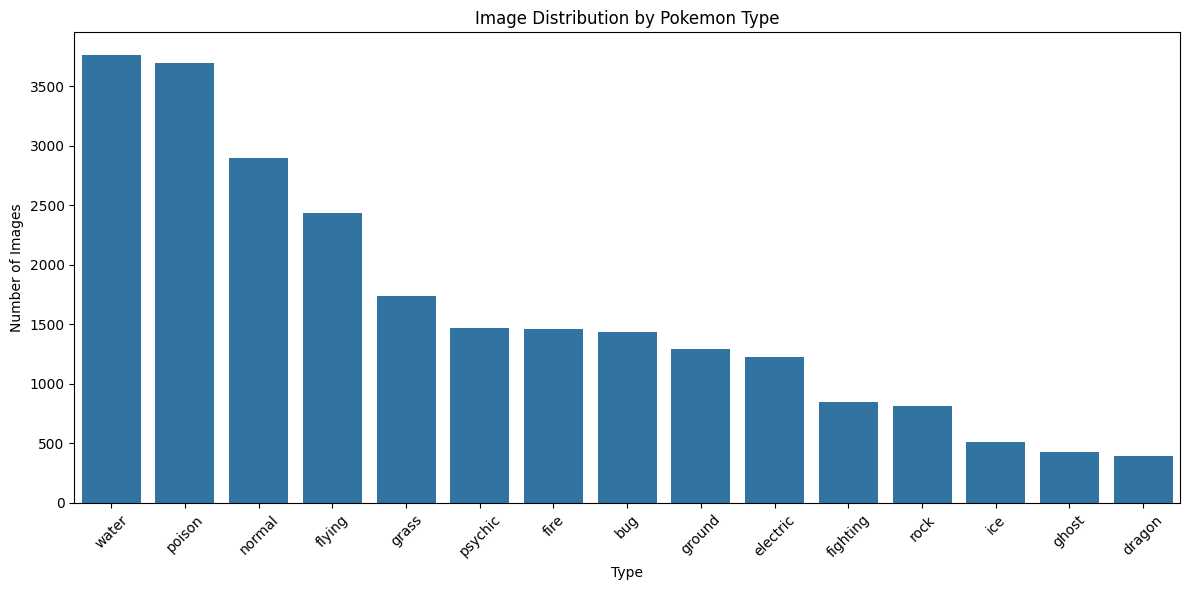

In [5]:
def count_images_per_type(all_types, pokemon_to_types, pokemon_to_images):
    """Count images per type"""
    type_to_image_count = {t: 0 for t in all_types}
    
    for pokemon, types in pokemon_to_types.items():
        if pokemon in pokemon_to_images:
            img_count = len(pokemon_to_images[pokemon])
            for t in types:
                type_to_image_count[t] += img_count

    return type_to_image_count

type_to_image_count = count_images_per_type(all_types, pokemon_to_types, pokemon_to_images)

print("\nImage distribution across types:")
for type_name, count in sorted(type_to_image_count.items(), key=lambda x: x[1], reverse=True):
    print(f"{type_name}: {count} images")

plt.figure(figsize=(12, 6))
types, counts = zip(*sorted(type_to_image_count.items(), key=lambda x: x[1], reverse=True))
sns.barplot(x=list(types), y=list(counts))
plt.title("Image Distribution by Pokemon Type")
plt.xlabel("Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Balancing

In [6]:
def filter_valid_types(all_types, type_to_image_count, min_images=MIN_IMAGES_PER_CLASS):
    """Filter types with sufficient images"""
    valid_types = [
        t for t, count in type_to_image_count.items() if count >= min_images
    ]
    print(f"\nTypes with at least {min_images} images: {valid_types}")
    return valid_types

valid_types = filter_valid_types(all_types, type_to_image_count)

def determine_target_counts(valid_types, type_to_image_count, min_images=MIN_IMAGES_PER_CLASS, max_images=MAX_IMAGES_PER_CLASS):
    """Determine target number of images per type"""
    type_to_target_count = {}
    
    for t in valid_types:
        available = type_to_image_count[t]
        if available <= max_images:
            type_to_target_count[t] = max(min_images, available)
        else:
            type_to_target_count[t] = max_images
    
    return type_to_target_count

type_to_target_count = determine_target_counts(valid_types, type_to_image_count)

print("\nTarget images per type:")
for type_name, count in sorted(type_to_target_count.items()):
    print(f"{type_name}: {count}")


Types with at least 1000 images: ['bug', 'electric', 'fire', 'flying', 'grass', 'ground', 'normal', 'poison', 'psychic', 'water']

Target images per type:
bug: 1436
electric: 1223
fire: 1457
flying: 2000
grass: 1734
ground: 1291
normal: 2000
poison: 2000
psychic: 1472
water: 2000


In [7]:
def group_pokemon_by_type(valid_types, pokemon_to_types, pokemon_to_images):
    type_to_pokemon = {t: [] for t in valid_types}
    
    for pokemon, types in pokemon_to_types.items():
        if pokemon in pokemon_to_images and len(pokemon_to_images[pokemon]) > 0:
            for t in types:
                if t in valid_types:
                    type_to_pokemon[t].append(pokemon)
                    
    return type_to_pokemon

type_to_pokemon = group_pokemon_by_type(valid_types, pokemon_to_types, pokemon_to_images)

print("\nNumber of Pokemon per type:")
for t, pokemon_list in type_to_pokemon.items():
    print(f"{t}: {len(pokemon_list)} Pokemon")


Number of Pokemon per type:
bug: 11 Pokemon
electric: 9 Pokemon
fire: 12 Pokemon
flying: 19 Pokemon
grass: 13 Pokemon
ground: 12 Pokemon
normal: 23 Pokemon
poison: 30 Pokemon
psychic: 14 Pokemon
water: 30 Pokemon


In [8]:
def calculate_pokemon_allocations(valid_types, type_to_pokemon, type_to_target_count, pokemon_to_images):
    """Calculate how many images to select from each Pokemon for each type"""
    pokemon_type_to_target_images = {}
    
    for t in valid_types:
        target_count = type_to_target_count[t]
        pokemon_list = type_to_pokemon[t]
        
        if not pokemon_list:
            continue
            
        pokemon_counts = {p: len(pokemon_to_images[p]) for p in pokemon_list}
        total_available = sum(pokemon_counts.values())
        
        pokemon_allocations = {}
        for p in pokemon_list:
            proportion = pokemon_counts[p] / total_available
            allocation = int(proportion * target_count)
            
            allocation = max(1, allocation)
            
            allocation = min(allocation, pokemon_counts[p])
            
            pokemon_allocations[p] = allocation
        
        total_allocated = sum(pokemon_allocations.values())
        
        for p in pokemon_list:
            pokemon_type_to_target_images[(p, t)] = pokemon_allocations[p]
            
    return pokemon_type_to_target_images

pokemon_type_to_target_images = calculate_pokemon_allocations(
    valid_types, type_to_pokemon, type_to_target_count, pokemon_to_images
)

Total balanced images: 11992

Final type distribution:
bug: 1205
electric: 1208
fire: 1438
flying: 1864
grass: 1139
ground: 1239
normal: 2000
poison: 2000
psychic: 1389
water: 1977


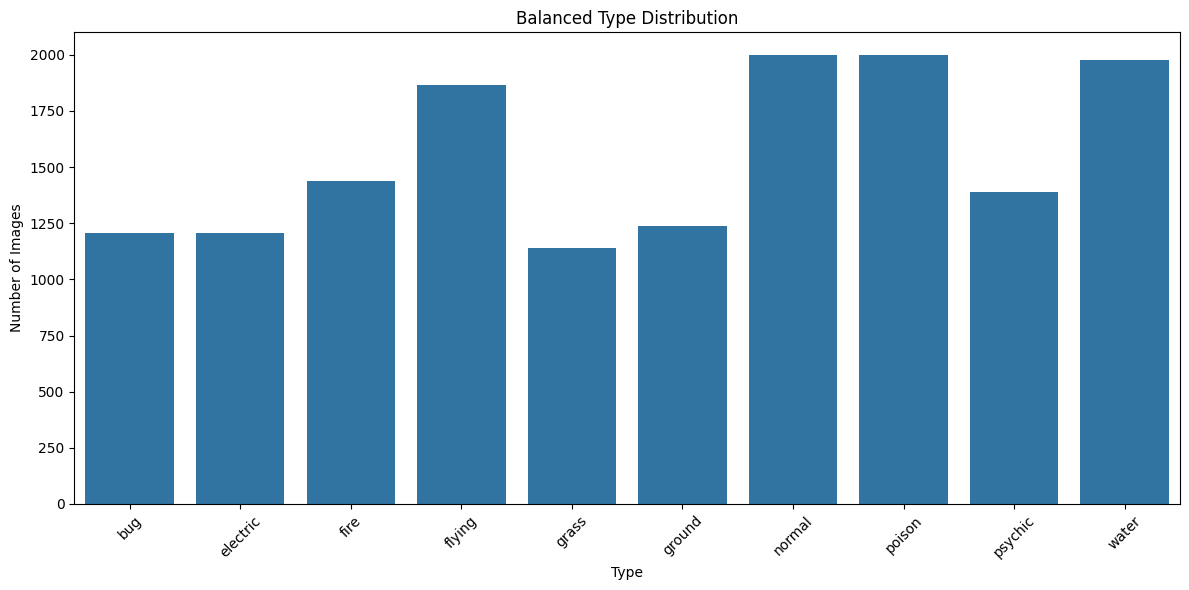

In [9]:
def create_balanced_dataset(valid_types, pokemon_to_types, pokemon_to_images, pokemon_type_to_target_images, type_to_target_count):
    """Create a balanced dataset with appropriate image selection"""
    selection_random_state = np.random.RandomState(seed=42)
    
    pokemon_to_selected_images = {p: 0 for p in pokemon_to_images.keys()}
    type_to_selected_images = {t: 0 for t in valid_types}
    selected_image_paths = set()
    balanced_image_paths = []
    balanced_labels = []
    
    for pokemon, types in pokemon_to_types.items():
        valid_types_for_pokemon = [t for t in types if t in valid_types]
        
        if not valid_types_for_pokemon or pokemon not in pokemon_to_images:
            continue
            
        if len(valid_types_for_pokemon) == 1:
            type_name = valid_types_for_pokemon[0]
            target_count = pokemon_type_to_target_images.get((pokemon, type_name), 0)
            
            if target_count == 0:
                continue
                
            available_images = pokemon_to_images[pokemon]
            
            if not available_images:
                continue
                
            num_to_select = min(target_count, len(available_images))
            selected_images = selection_random_state.choice(
                available_images, 
                size=num_to_select, 
                replace=False
            )
            
            for img_path in selected_images:
                if img_path not in selected_image_paths:
                    selected_image_paths.add(img_path)
                    balanced_image_paths.append(img_path)
                    balanced_labels.append(valid_types_for_pokemon)
                    pokemon_to_selected_images[pokemon] += 1
                    type_to_selected_images[type_name] += 1
    
    for pokemon, types in pokemon_to_types.items():
        valid_types_for_pokemon = [t for t in types if t in valid_types]
        
        if (not valid_types_for_pokemon or pokemon not in pokemon_to_images 
            or len(valid_types_for_pokemon) != 2):
            continue
            
        type1, type2 = valid_types_for_pokemon
        target1 = pokemon_type_to_target_images.get((pokemon, type1), 0)
        target2 = pokemon_type_to_target_images.get((pokemon, type2), 0)
        
        target_count = max(1, (target1 + target2) // 2)
        
        remaining_type1 = type_to_target_count.get(type1, 0) - type_to_selected_images[type1]
        remaining_type2 = type_to_target_count.get(type2, 0) - type_to_selected_images[type2]
        
        target_count = min(target_count, remaining_type1, remaining_type2)
        
        if target_count <= 0:
            continue
            
        available_images = [
            img for img in pokemon_to_images[pokemon] 
            if img not in selected_image_paths
        ]
        
        if not available_images:
            continue
            
        num_to_select = min(target_count, len(available_images))
        selected_images = selection_random_state.choice(
            available_images, 
            size=num_to_select, 
            replace=False
        )
        
        for img_path in selected_images:
            selected_image_paths.add(img_path)
            balanced_image_paths.append(img_path)
            balanced_labels.append(valid_types_for_pokemon)
            pokemon_to_selected_images[pokemon] += 1
            type_to_selected_images[type1] += 1
            type_to_selected_images[type2] += 1
            
    return balanced_image_paths, balanced_labels, type_to_selected_images, pokemon_to_selected_images

balanced_image_paths, balanced_labels, type_to_selected_images, pokemon_to_selected_images = create_balanced_dataset(
    valid_types, pokemon_to_types, pokemon_to_images, pokemon_type_to_target_images, type_to_target_count
)

print(f"Total balanced images: {len(balanced_image_paths)}")

print("\nFinal type distribution:")
for type_name, count in sorted(type_to_selected_images.items()):
    print(f"{type_name}: {count}")

plt.figure(figsize=(12, 6))
types, counts = zip(*sorted(type_to_selected_images.items()))
sns.barplot(x=list(types), y=list(counts))
plt.title("Balanced Type Distribution")
plt.xlabel("Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Prep (Cont.)

In [10]:
mlb = MultiLabelBinarizer(classes=valid_types)
encoded_labels = mlb.fit_transform(balanced_labels)
print(f"Label shape: {encoded_labels.shape}")

type_counts = encoded_labels.sum(axis=0)
print("\nFinal class distribution:")
for i, count in enumerate(type_counts):
    print(f"{valid_types[i]}: {count}")

X_train, X_temp, y_train, y_temp = train_test_split(
    balanced_image_paths,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=None,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=None
)

print(f"\nTraining set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

Label shape: (11992, 10)

Final class distribution:
bug: 1205
electric: 1208
fire: 1438
flying: 1864
grass: 1139
ground: 1239
normal: 2000
poison: 2000
psychic: 1389
water: 1977

Training set: 9593 images
Validation set: 1199 images
Test set: 1200 images


## Image Loading and Preprocessing

In [11]:
def create_data_generators():
    """Create data generators with appropriate augmentation"""
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode="nearest",
    )

    val_test_datagen = ImageDataGenerator()
    
    return train_datagen, val_test_datagen

def load_and_preprocess_image(img_path, datagen=None):
    """Load, resize, and preprocess a single image"""
    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize(IMG_SIZE)

        img_array = np.array(img, dtype=np.float32) / 255.0

        if datagen is not None and (datagen.preprocessing_function is not None or datagen.rotation_range > 0):
            img_array = datagen.random_transform(img_array)
            
        return img_array
    except Exception as e:
        print(f"Error loading image {img_path}: {str(e)}")
        return np.zeros((*IMG_SIZE, 3), dtype=np.float32)

## Data Splitting and Generators

In [12]:
def generate_from_paths_and_labels(image_paths, labels, batch_size, datagen):
    """Custom generator to create batches from image paths and labels"""
    batch_random_state = np.random.RandomState(seed=42)

    while True:
        indexes = batch_random_state.randint(0, len(image_paths), batch_size)
        batch_paths = [image_paths[i] for i in indexes]
        batch_labels = labels[indexes]

        batch_images = []
        for img_path in batch_paths:
            img_array = load_and_preprocess_image(img_path, datagen)
            batch_images.append(img_array)

        batch_images = np.array(batch_images, dtype=np.float32)

        yield batch_images, batch_labels

def prepare_training_data(X_train, y_train, X_val, y_val, X_test, y_test):
    """Prepare training, validation, and test generators"""
    train_datagen, val_test_datagen = create_data_generators()
    
    train_generator = generate_from_paths_and_labels(
        X_train, y_train, BATCH_SIZE, train_datagen
    )
    val_generator = generate_from_paths_and_labels(
        X_val, y_val, BATCH_SIZE, val_test_datagen
    )
    test_generator = generate_from_paths_and_labels(
        X_test, y_test, BATCH_SIZE, val_test_datagen
    )
    
    return train_generator, val_generator, test_generator, train_datagen, val_test_datagen

train_generator, val_generator, test_generator, train_datagen, val_test_datagen = prepare_training_data(
    X_train, y_train, X_val, y_val, X_test, y_test
)

## CNN Architecture

In [13]:
def build_model(num_classes):
    """Build CNN model for Pokemon type multilabel classification"""
    inputs = layers.Input(shape=(*IMG_SIZE, 3))

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation="relu")(x)

    outputs = layers.Dense(num_classes, activation="sigmoid")(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    model.summary()

    return model

num_classes = len(valid_types)
model = build_model(num_classes)

model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,605,770 (9.94 MB)

 Trainable params: 2,605,770 (9.94 MB)

 Non-trainable params: 0 (0.00 B)

## Training and Evaluation

In [14]:
def create_callbacks(output_dir):
    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=0.01,
        restore_best_weights=True,
        verbose=1,
    )

    model_checkpoint = callbacks.ModelCheckpoint(
        os.path.join(output_dir, "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    )

    tensorboard_callback = callbacks.TensorBoard(
        log_dir=os.path.join(output_dir, "logs"), histogram_freq=1
    )
    
    return [early_stopping, model_checkpoint, tensorboard_callback]

In [15]:
def plot_training_history(history, output_dir):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training and Validation Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Validation Loss")

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "training_history.png"))
    plt.show()

Training for 20 epochs with 299 steps per epoch
Validation with 37 steps
Epoch 1/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.1605 - loss: 0.4194
Epoch 1: val_loss improved from inf to 0.33284, saving model to output/run_20250502_004254/best_model.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 103s 344ms/step - accuracy: 0.1607 - loss: 0.4193 - val_accuracy: 0.3497 - val_loss: 0.3328
Epoch 2/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.3274 - loss: 0.3297
Epoch 2: val_loss improved from 0.33284 to 0.30245, saving model to output/run_20250502_004254/best_model.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 104s 347ms/step - accuracy: 0.3275 - loss: 0.3297 - val_accuracy: 0.4113 - val_loss: 0.3025
Epoch 3/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.3693 - loss: 0.3116
Epoch 3: val_loss improved from 0.30245 to 0.29272, saving model to output/run_20250502_004254/best_model.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 102s 342ms/step - accuracy: 0.3694 - loss: 0.3116 - val_accu

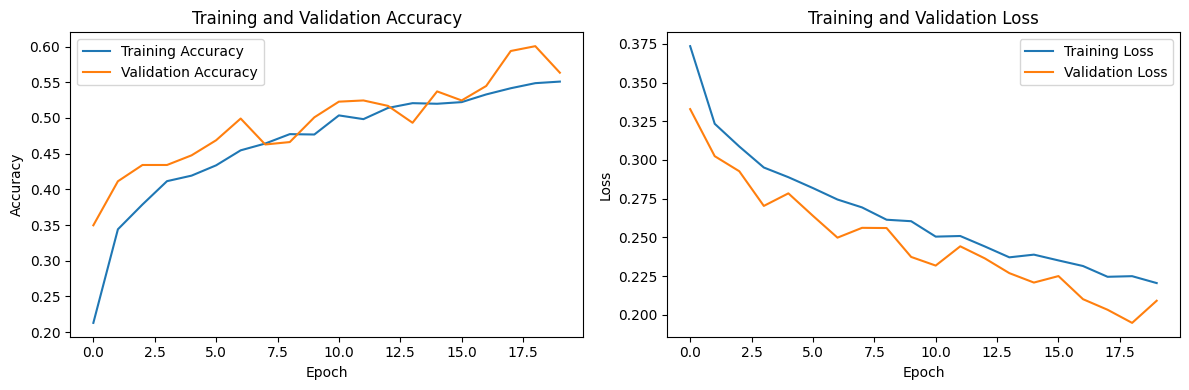

In [16]:
model_callbacks = create_callbacks(output_dir)

steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)
validation_steps = max(1, len(X_val) // BATCH_SIZE)

print(f"Training for {EPOCHS} epochs with {steps_per_epoch} steps per epoch")
print(f"Validation with {validation_steps} steps")

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=model_callbacks,
    verbose=1
)

test_steps = max(1, len(X_test) // BATCH_SIZE)
test_loss, test_acc = model.evaluate(test_generator, steps=test_steps)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

with open(os.path.join(output_dir, "evaluation_results.txt"), "w") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\n")
    f.write(f"Test loss: {test_loss:.4f}\n")

model.save(os.path.join(output_dir, "model.keras"))
print(f"Model saved to {os.path.join(output_dir, 'model.keras')}")

np.save(os.path.join(output_dir, "label_encoder_classes.npy"), mlb.classes_)

np.save(os.path.join(output_dir, "valid_types.npy"), np.array(valid_types))

plot_training_history(history, output_dir)

## Model Evaluation

In [17]:
def get_predictions(model, X_test, datagen=None):
    """Get predictions for all test images"""
    all_probs = []
    batch_size = BATCH_SIZE

    for i in range(0, len(X_test), batch_size):
        batch_paths = X_test[i : i + batch_size]
        batch_images = []

        for img_path in batch_paths:
            img_array = load_and_preprocess_image(img_path)
            batch_images.append(img_array)

        batch_images = np.array(batch_images, dtype=np.float32)
        batch_probs = model.predict(batch_images)
        all_probs.extend(batch_probs)

    all_probs = np.array(all_probs)

    threshold = 0.5
    y_pred = (all_probs >= threshold).astype(int)

    return y_pred, all_probs

In [18]:
def generate_metrics(y_test, y_pred, label_encoder, output_dir):
    """Generate and save metrics for multilabel classification"""
    class_names = label_encoder.classes_
    
    report = classification_report(
        y_test, y_pred, 
        target_names=class_names, 
        output_dict=True,
        zero_division=0
    )
    
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(output_dir, "classification_report.csv"))
    
    print("\nClassification Report:")
    print(
        classification_report(y_test, y_pred, target_names=class_names, zero_division=0)
    )

    mcm = multilabel_confusion_matrix(y_test, y_pred)

    fig, axes = plt.subplots(
        nrows=int(np.ceil(len(class_names) / 3)),
        ncols=3,
        figsize=(15, 5 * int(np.ceil(len(class_names) / 3))),
    )
    axes = axes.flatten()

    for i, (cm, class_name) in enumerate(zip(mcm, class_names)):
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes[i],
            cbar=False,
        )
        axes[i].set_title(f"{class_name}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("True")
        axes[i].set_xticklabels(["Negative", "Positive"])
        axes[i].set_yticklabels(["Negative", "Positive"])

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "confusion_matrices.png"), dpi=300)
    plt.show()
    
    metrics = {
        "class": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "support": [],
    }
    
    for i, class_name in enumerate(class_names):
        metrics["class"].append(class_name)
        metrics["precision"].append(report[class_name]["precision"])
        metrics["recall"].append(report[class_name]["recall"])
        metrics["f1"].append(report[class_name]["f1-score"])
        metrics["support"].append(report[class_name]["support"])
    
    metrics_df = pd.DataFrame(metrics)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(metrics_df["class"], metrics_df["f1"], color="skyblue")
    plt.title("F1 Score by Class")
    plt.xlabel("Class")
    plt.ylabel("F1 Score")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 0.01,
            f"{height:.2f}",
            ha="center", 
            va="bottom",
            rotation=45
        )
        
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "f1_scores.png"))
    plt.show()
    
    avg_metrics = {
        "Metric": ["Precision", "Recall", "F1 Score"],
        "Micro Avg": [
            report["micro avg"]["precision"],
            report["micro avg"]["recall"],
            report["micro avg"]["f1-score"],
        ],
        "Macro Avg": [
            report["macro avg"]["precision"],
            report["macro avg"]["recall"],
            report["macro avg"]["f1-score"],
        ],
        "Weighted Avg": [
            report["weighted avg"]["precision"],
            report["weighted avg"]["recall"],
            report["weighted avg"]["f1-score"],
        ],
    }
    
    avg_df = pd.DataFrame(avg_metrics)
    print("\nAverage Metrics:")
    print(avg_df)
    
    avg_df.to_csv(os.path.join(output_dir, "average_metrics.csv"), index=False)
    
    plt.figure(figsize=(10, 6))
    x = np.arange(len(avg_metrics["Metric"]))
    width = 0.25
    
    plt.bar(x - width, avg_metrics["Micro Avg"], width, label="Micro Avg")
    plt.bar(x, avg_metrics["Macro Avg"], width, label="Macro Avg")
    plt.bar(x + width, avg_metrics["Weighted Avg"], width, label="Weighted Avg")
    
    plt.ylabel("Score")
    plt.title("Average Metrics Comparison")
    plt.xticks(x, avg_metrics["Metric"])
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "average_metrics.png"))
    plt.show()
    
    return report, mcm, metrics_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━

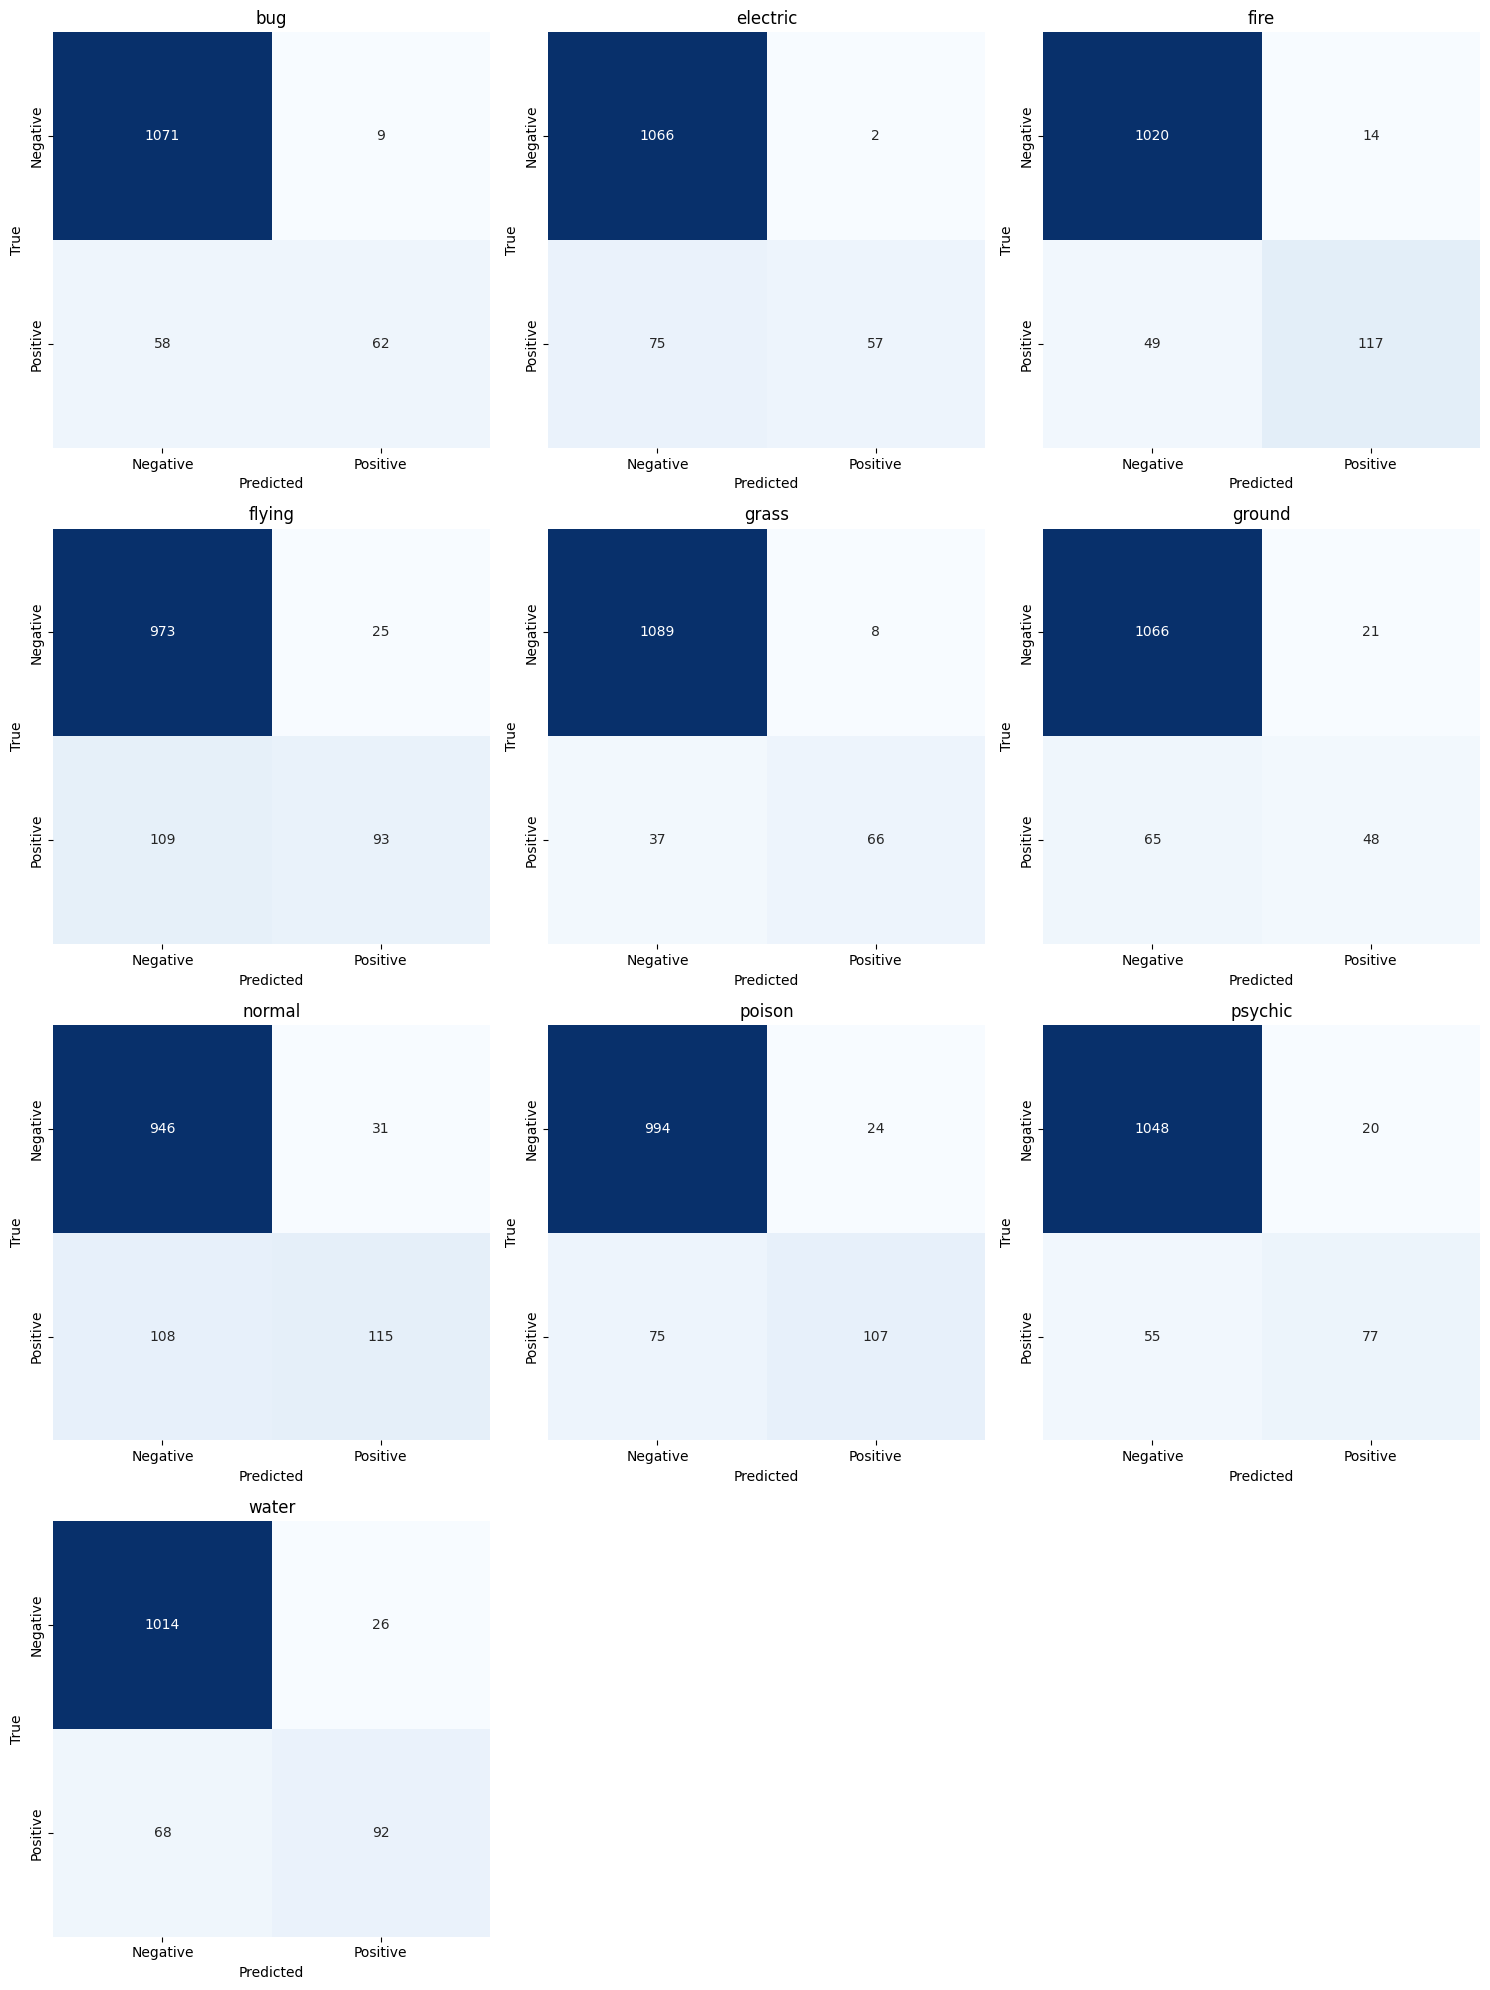

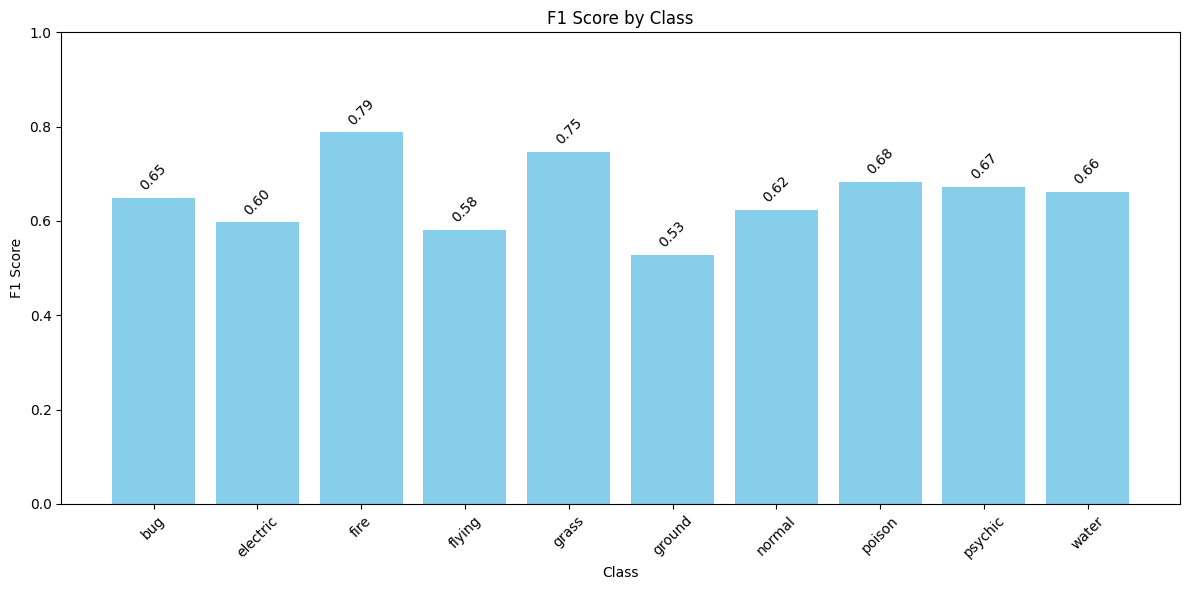


Average Metrics:
      Metric  Micro Avg  Macro Avg  Weighted Avg
0  Precision   0.822485   0.828609      0.824584
1     Recall   0.544031   0.544120      0.544031
2   F1 Score   0.654888   0.652981      0.651930


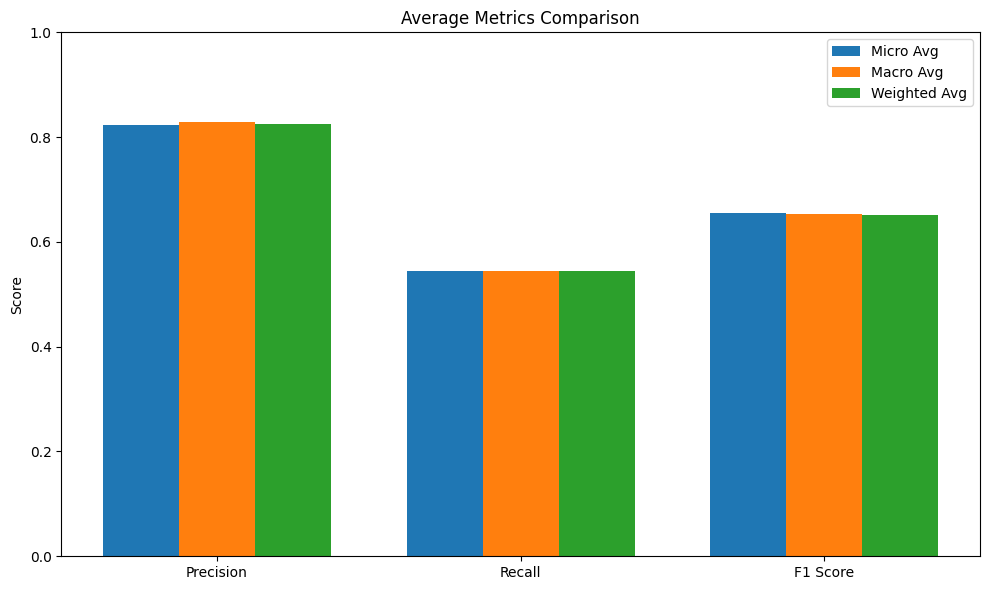

In [19]:
y_pred, y_probs = get_predictions(model, X_test, val_test_datagen)
report, confusion_matrices, metrics_df = generate_metrics(y_test, y_pred, mlb, output_dir)

## Prediction Logits

In [21]:
def save_test_predictions(model, X_test, y_test, label_encoder, output_dir):
    """Save test predictions to CSV"""
    class_names = label_encoder.classes_
    
    y_pred, all_probs = get_predictions(model, X_test)
    
    results = []
    
    for i in range(len(X_test)):
        img_path = X_test[i]
        
        true_types = [class_names[j] for j in range(len(class_names)) if y_test[i, j] == 1]
        
        pred_types = [class_names[j] for j in range(len(class_names)) if y_pred[i, j] == 1]
        
        exact_match = (y_test[i] == y_pred[i]).all()
        
        result = {
            "image_path": img_path,
            "true_types": ", ".join(true_types),
            "predicted_types": ", ".join(pred_types),
            "exact_match": exact_match,
        }
        
        for j, class_name in enumerate(class_names):
            result[f"{class_name}_prob"] = all_probs[i, j]
        
        results.append(result)
    
    results_df = pd.DataFrame(results)
    
    results_df.to_csv(os.path.join(output_dir, "test_predictions.csv"), index=False)
    print(f"Saved predictions for {len(results)} test examples")
    
    exact_match_count = results_df["exact_match"].sum()
    exact_match_accuracy = exact_match_count / len(results_df)
    print(f"Exact match accuracy: {exact_match_accuracy:.4f} ({exact_match_count}/{len(results_df)})")
        
    return results, all_probs

In [36]:
test_results, test_probs = save_test_predictions(model, X_test, y_test, mlb, output_dir)
test_results_df = pd.DataFrame(test_results)
print("Test Predictions Sample:")
display(test_results_df.head())

prob_columns = [col for col in test_results_df.columns if col.endswith('_prob')]
prob_stats = test_results_df[prob_columns].describe()
print("\nProbability Statistics:")
display(prob_stats)

exact_match_pct = test_results_df['exact_match'].mean() * 100
print(f"\nExact match percentage: {exact_match_pct:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━

,image_path,true_types,predicted_types,exact_match,bug_prob,electric_prob,fire_prob,flying_prob,grass_prob,ground_prob,normal_prob,poison_prob,psychic_prob,water_prob
0,data/Electrode/00000176.jpg,electric,,False,0.077753,0.092399,0.001273,0.181283,0.195004,0.010640,0.048077,0.021848,0.180843,0.131972
1,data/Clefairy/7580662a6ec64e8698c3a2e71554a064...,normal,normal,True,0.000887,0.000647,0.000032,0.000332,0.029408,0.000825,0.980493,0.000139,0.099785,0.013864
2,data/Magneton/00000003.png,electric,,False,0.025796,0.433151,0.000734,0.062477,0.019536,0.082131,0.004404,0.011185,0.015694,0.310946
3,data/Wartortle/00000214.jpg,water,,False,0.008889,0.102603,0.000519,0.048361,0.000401,0.299988,0.001420,0.037245,0.016795,0.316863
4,data/Caterpie/3cdb06a0930a42ff8831b04dc9e565df...,bug,bug,True,0.920539,0.000996,0.000872,0.033323,0.184994,0.007858,0.004933,0.234291,0.023646,0.003726



Probability Statistics:


,bug_prob,electric_prob,fire_prob,flying_prob,grass_prob,ground_prob,normal_prob,poison_prob,psychic_prob,water_prob
count,1200.000000,1200.000000,1.200000e+03,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.115485,0.081723,1.229796e-01,0.210447,0.077539,0.097124,0.178166,0.144765,0.128626,0.160185
std,0.203242,0.177340,2.618311e-01,0.212365,0.208581,0.167318,0.245975,0.248188,0.209253,0.224454
min,0.000019,0.000003,8.417439e-07,0.000021,0.000005,0.000035,0.000037,0.000005,0.000007,0.000331
25%,0.010918,0.002588,6.593178e-04,0.049417,0.001367,0.006610,0.011026,0.007509,0.004535,0.021203
50%,0.039632,0.010801,4.553709e-03,0.140767,0.006467,0.026721,0.062579,0.035303,0.028309,0.059245
75%,0.114602,0.057012,5.124926e-02,0.302016,0.029784,0.095874,0.247152,0.127143,0.147048,0.194791
max,0.998419,0.992087,9.967548e-01,0.993294,0.999460,0.905731,0.982228,0.998911,0.975518,0.995290



Exact match percentage: 49.33%


## Logit Predicition Sample Visualization

In [23]:
def display_predictions(model, X_test, y_test, label_encoder, output_dir, num_examples=6):
    """Display predictions on a random sample of test images"""
    class_names = label_encoder.classes_
    
    random_indices = np.random.choice(len(X_test), size=num_examples, replace=False)
    
    y_pred, all_probs = get_predictions(model, [X_test[i] for i in random_indices])
    
    plt.figure(figsize=(18, 3*num_examples))
    
    for i, idx in enumerate(random_indices):
        img_path = X_test[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize(IMG_SIZE, Image.LANCZOS)
        
        true_labels = [class_names[j] for j in range(len(class_names)) if y_test[idx, j] == 1]
        pred_labels = [class_names[j] for j in range(len(class_names)) if y_pred[i, j] == 1]
        
        top_indices = np.argsort(all_probs[i])[::-1][:3]
        top_preds = [(class_names[j], all_probs[i, j]) for j in top_indices]
        
        plt.subplot(num_examples, 3, i*3 + 1)
        plt.imshow(np.array(img))
        plt.title(f"Pokemon Image\n{os.path.basename(img_path)}")
        plt.axis("off")

        plt.subplot(num_examples, 3, i*3 + 2)
        plt.axis("off")
        is_correct = set(true_labels) == set(pred_labels)
        color = "green" if is_correct else "red"
        title = "CORRECT" if is_correct else "INCORRECT"
        plt.text(0.5, 0.9, title, ha="center", va="center", fontsize=14, color=color, fontweight="bold")
        
        true_text = f"True: {', '.join(true_labels)}"
        pred_text = f"Pred: {', '.join(pred_labels)}"
        
        plt.text(0.5, 0.7, true_text, ha="center", va="center", fontsize=12)
        plt.text(0.5, 0.5, pred_text, ha="center", va="center", fontsize=12, color=color)
        
        plt.subplot(num_examples, 3, i*3 + 3)
        types = [t for t, _ in top_preds]
        scores = [s for _, s in top_preds]
        
        y_pos = np.arange(len(types))
        bars = plt.barh(y_pos, scores, align="center")
        plt.yticks(y_pos, types)
        plt.xlabel("Probability")
        plt.title("Top 3 Predictions")
        plt.xlim(0, 1)

        for j, (t, bar) in enumerate(zip(types, bars)):
            if t in true_labels:
                bar.set_color("green")
            else:
                bar.set_color("red")
        
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "prediction_examples.png"), dpi=300)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


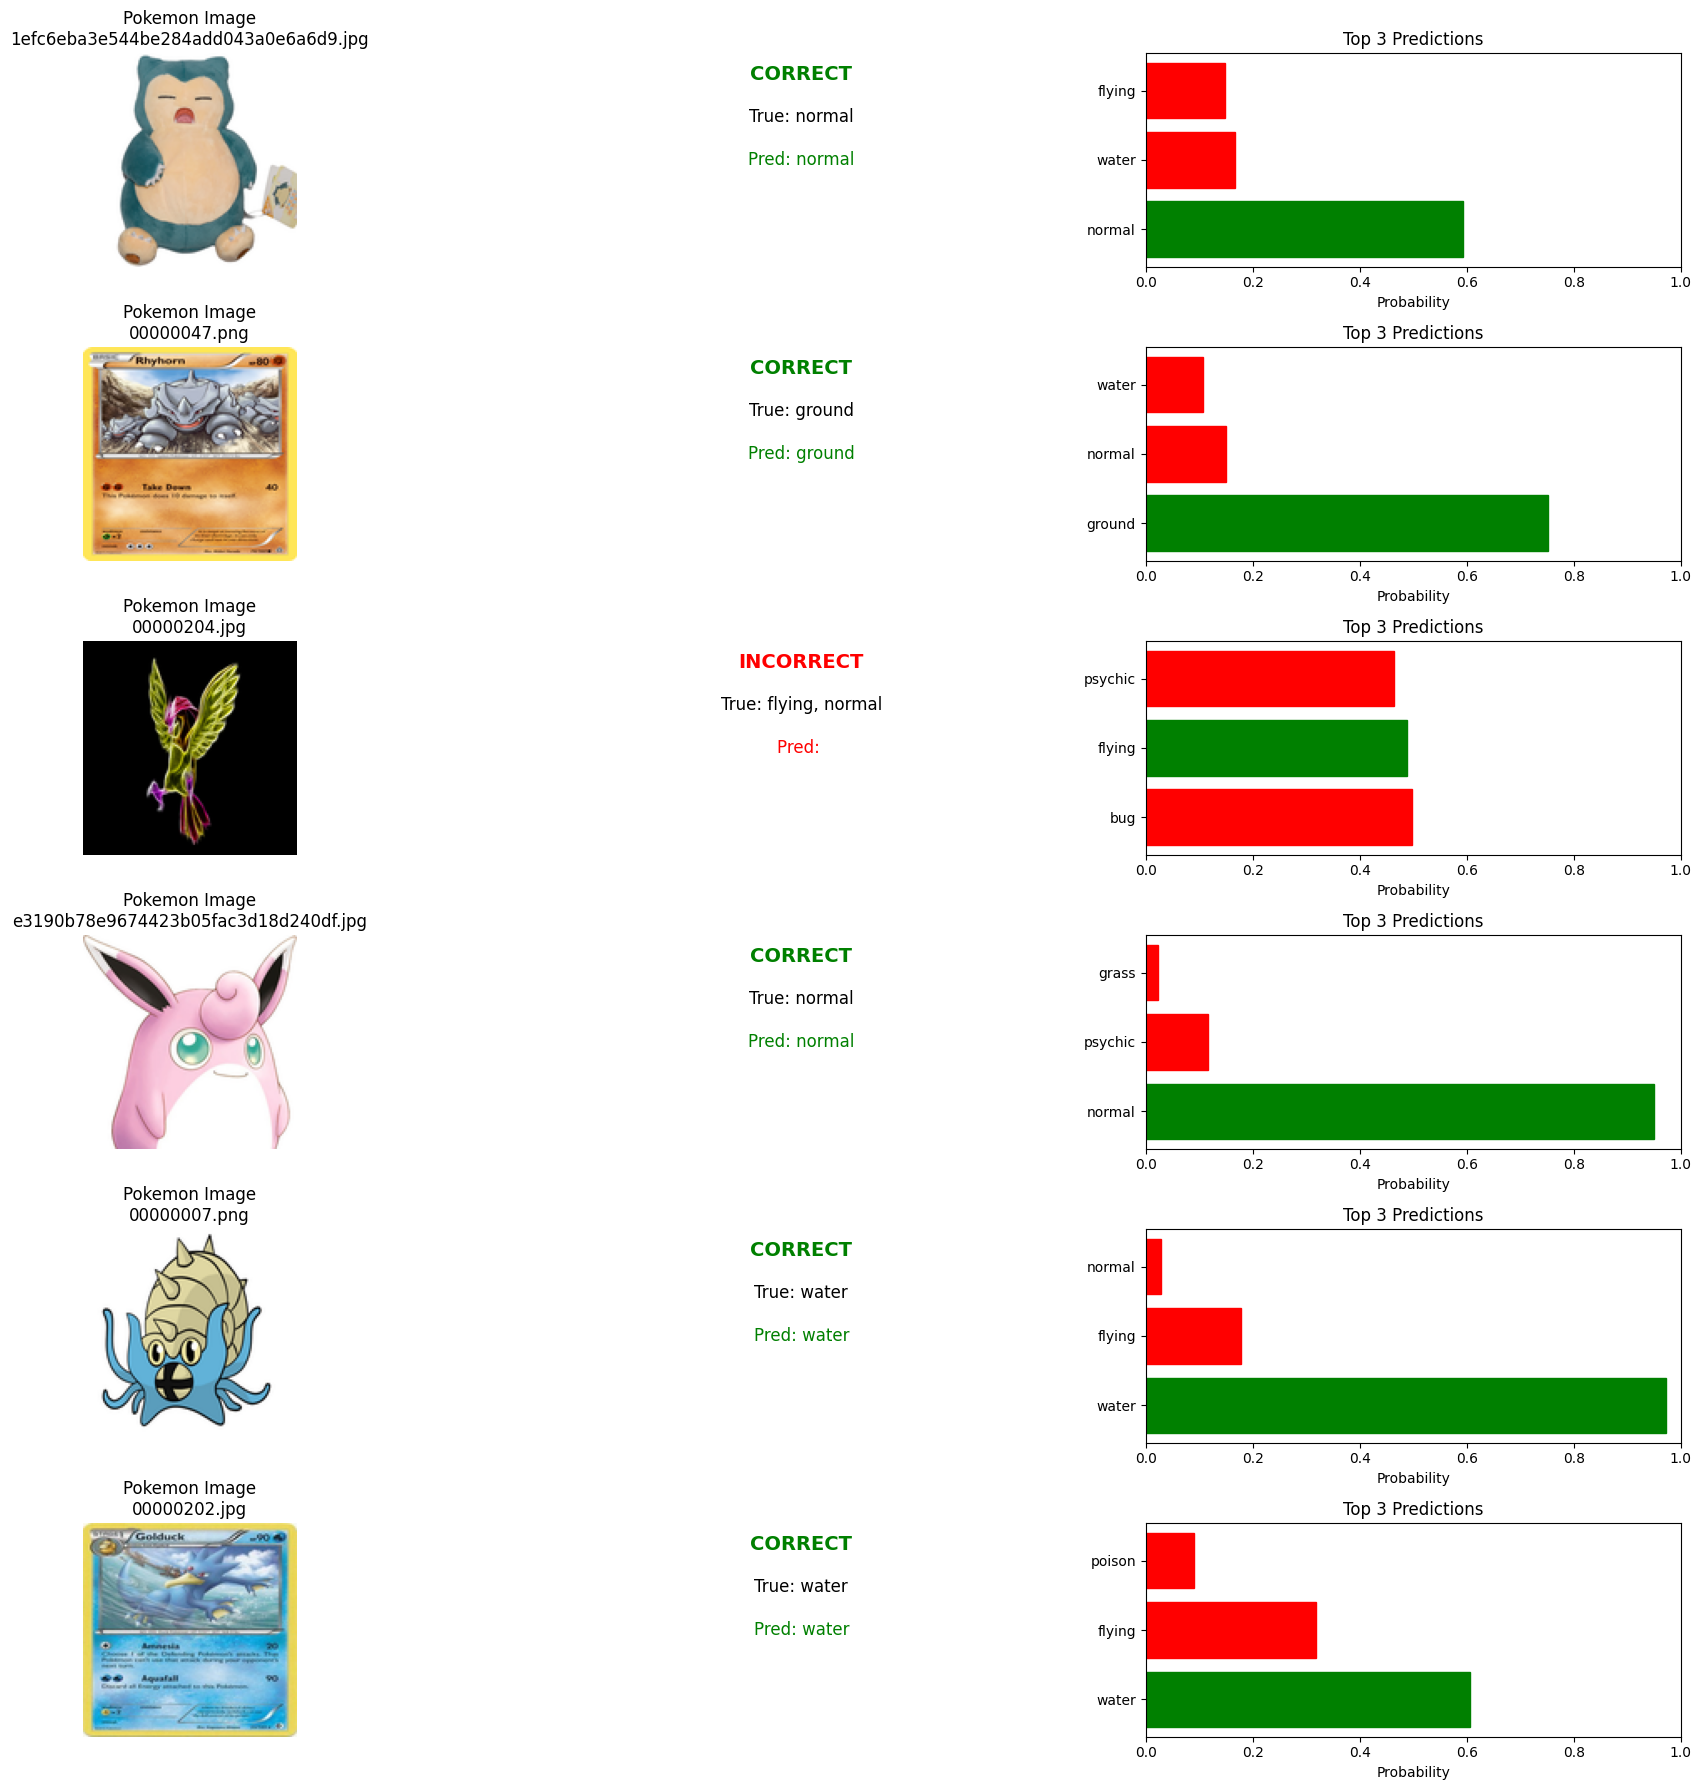

In [38]:
display_predictions(model, X_test, y_test, mlb, output_dir, num_examples=6)

## Single Image Prediction

In [25]:
def load_and_preprocess_image(img_path, datagen=None):
    """Load, resize, and preprocess a single image"""
    img = Image.open(img_path).convert("RGB")
    img = img.resize(IMG_SIZE, Image.LANCZOS)
    img_array = np.array(img, dtype=np.float32)
    
    img_array /= 255.0
    
    if datagen is not None:
        img_array = datagen.random_transform(img_array)
    
    return img_array

In [26]:
def predict_single_image(image_path, model=None, classes=None, show_image=True, top_k=5, output_dir=None):
    """Predict the types of a single Pokemon image"""
    if output_dir is None:
        output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)
    
    if model is None:
        model_paths = [
            "model.keras",
            "best_model.keras",
            os.path.join(output_dir, "model.keras"),
            os.path.join(output_dir, "best_model.keras")
        ]
        
        model_path = None
        for path in model_paths:
            if os.path.exists(path):
                model_path = path
                break
                
        if model_path is None:
            print("Error: No model found. Please train the model first or provide a model.")
            return None, None
            
        model = tf.keras.models.load_model(model_path)
        print(f"Loaded model from {model_path}")
    
    if classes is None:
        class_paths = [
            "valid_types.npy",
            "label_encoder_classes.npy",
            os.path.join(output_dir, "valid_types.npy"),
            os.path.join(output_dir, "label_encoder_classes.npy")
        ]
        
        class_path = None
        for path in class_paths:
            if os.path.exists(path):
                class_path = path
                break
                
        if class_path is None:
            print("Error: No class file found. Please train the model first or provide classes.")
            return None, None
            
        classes = np.load(class_path, allow_pickle=True)
        print(f"Loaded classes from {class_path}")

    try:
        img_array = load_and_preprocess_image(image_path)
        img_batch = np.expand_dims(img_array, axis=0)

        prediction_probs = model.predict(img_batch)[0]

        sorted_indices = np.argsort(prediction_probs)[::-1]
        threshold = 0.5
        predicted_types = [
            classes[i] for i, prob in enumerate(prediction_probs) if prob >= threshold
        ]

        if not predicted_types and len(classes) > 0:
            top_idx = sorted_indices[0]
            predicted_types = [classes[top_idx]]
            print(f"No types exceeded threshold. Taking highest: {classes[top_idx]} ({prediction_probs[top_idx]:.2f})")

        print(f"\nPredicted types for {os.path.basename(image_path)}: {', '.join(predicted_types)}")

        if show_image:
            plt.figure(figsize=(10, 6))
            
            plt.subplot(1, 2, 1)
            plt.imshow(img_array)
            plt.title(f"Predicted Types:\n{', '.join(predicted_types)}")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            
            top_indices = sorted_indices[:top_k]
            top_probs = prediction_probs[top_indices]
            top_classes = classes[top_indices]

            y_pos = np.arange(len(top_indices))
            plt.barh(y_pos, top_probs, align="center")
            plt.yticks(y_pos, top_classes)
            plt.xlabel("Probability")
            plt.title("Top Predictions")
            plt.xlim(0, 1)

            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, "single_prediction.png"))
            plt.show()

        print(f"\nAll type probabilities for {os.path.basename(image_path)}:")
        print(f"{'Type':<15} {'Probability':<15} {'Confidence'}")
        print("-" * 45)

        for i in range(min(len(classes), len(sorted_indices))):
            idx = sorted_indices[i]
            class_name = classes[idx]
            prob = prediction_probs[idx]
            stars = int(prob * 50)
            confidence = "*" * stars
            print(f"{class_name:<15} {prob:.6f} {confidence}")

        return classes, prediction_probs

    except Exception as e:
        print(f"Error predicting image {image_path}: {str(e)}")
        return None, None

In [30]:
def show_labeled_prediction(image_path, classes, prediction_probs, output_dir=None):
    """Display an image with predicted types overlaid as a clean label"""
    if not os.path.exists(image_path):
        print(f"Image file {image_path} not found.")
        return
        
    if output_dir is None:
        output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)
    
    sorted_indices = np.argsort(prediction_probs)[::-1]
    threshold = 0.5
    predicted_types = [
        classes[i] for i, prob in enumerate(prediction_probs) if prediction_probs[i] >= threshold
    ]
    
    if not predicted_types and len(classes) > 0:
        top_idx = sorted_indices[0]
        predicted_types = [classes[top_idx]]
        top_prob = prediction_probs[top_idx]
        print(f"No types exceeded threshold. Using top prediction: {classes[top_idx]} ({top_prob:.2f})")

    img = Image.open(image_path).convert("RGB")
    
    plt.figure(figsize=(8, 8))
    
    plt.imshow(img)
    
    top3_indices = sorted_indices[:3]
    label_text = ""
    
    for i, idx in enumerate(top3_indices):
        type_name = classes[idx]
        probability = prediction_probs[idx]
        label_text += f"{type_name}: {probability:.2f}\n"
    
    props = dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7)
    plt.text(0.05, 0.95, label_text, transform=plt.gca().transAxes, fontsize=14,
             color='white', verticalalignment='top', bbox=props)
        
    plt.title(f"Predicted: {', '.join(predicted_types)}", fontsize=16)
    
    plt.axis('off')
    
    labeled_img_path = os.path.join(output_dir, f"labeled_{os.path.basename(image_path)}")
    plt.tight_layout()
    plt.savefig(labeled_img_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Labeled image saved to: {labeled_img_path}")
    return labeled_img_path

Predicting types for jdiglett.png...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Predicted types for jdiglett.png: poison


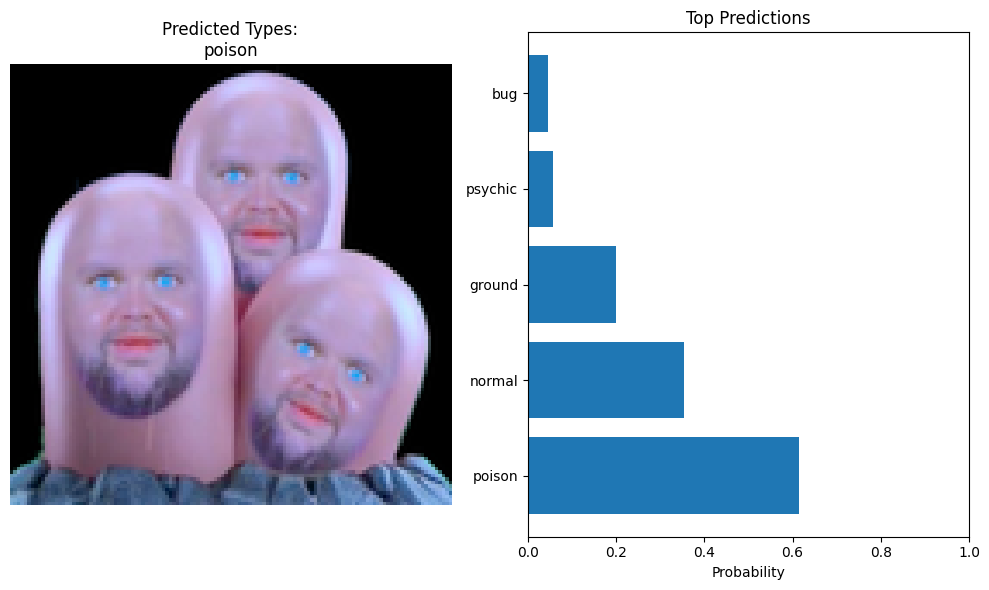


All type probabilities for jdiglett.png:
Type            Probability     Confidence
---------------------------------------------
poison          0.615416 ******************************
normal          0.353351 *****************
ground          0.200744 **********
psychic         0.057081 **
bug             0.045983 **
water           0.018662 
flying          0.013196 
electric        0.000762 
fire            0.000691 
grass           0.000182 


In [ ]:
jd_vance = "jdiglett.png"
if os.path.exists(jd_vance):
    print(f"Predicting types for {jd_vance}...")
    classes, prediction_probs = predict_single_image(jd_vance, model, mlb.classes_, output_dir=output_dir)

## Predictions Across All Generations

In [33]:
def visualize_sample_predictions(results_df, output_dir):
    """Create visualizations of sample predictions"""
    sample_viz_dir = os.path.join(output_dir, "sample_predictions")
    os.makedirs(sample_viz_dir, exist_ok=True)
    
    results_df['top_type'] = results_df['pred1']
    
    type_counts = results_df['top_type'].value_counts()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=type_counts.index, y=type_counts.values)
    plt.title("Distribution of Predicted Types in Sample Images")
    plt.xlabel("Pokémon Type")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "sample_type_distribution.png"))
    plt.show()
    
    num_images = min(25, len(results_df))
    grid_size = int(np.ceil(np.sqrt(num_images)))
    
    plt.figure(figsize=(15, 15))
    for i in range(num_images):
        plt.subplot(grid_size, grid_size, i+1)
        
        img_path = results_df.iloc[i]['image_path']
        pred_types = results_df.iloc[i]['predicted_types']
        top_pred = results_df.iloc[i]['pred1']
        top_prob = results_df.iloc[i]['prob1']
        
        try:
            img = Image.open(img_path).convert("RGB")
            plt.imshow(img)
            plt.title(f"{top_pred}\n({top_prob:.2f})", fontsize=10)
            plt.axis("off")
        except Exception as e:
            print(f"Error displaying image {img_path}: {str(e)}")
            plt.text(0.5, 0.5, "Error loading image", ha='center', va='center')
            
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "sample_predictions_grid.png"))
    plt.show()

In [34]:
def predict_sample_folder(model=None, classes=None, sample_folder="sample", output_dir=None):
    """Predict types for all images in the sample folder recursively"""
    if output_dir is None:
        output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)

    print(f"\nPredicting types for all images in the {sample_folder} folder (including subdirectories)...")

    if model is None:
        model_paths = [
            "model.keras",
            "best_model.keras",
            os.path.join(output_dir, "model.keras"),
            os.path.join(output_dir, "best_model.keras")
        ]

        model_path = None
        for path in model_paths:
            if os.path.exists(path):
                model_path = path
                break

        if model_path is None:
            print("Error: No model found. Please train the model first or provide a model.")
            return None

        model = tf.keras.models.load_model(model_path)
        print(f"Loaded model from {model_path}")

    if classes is None:
        class_paths = [
            "valid_types.npy",
            "label_encoder_classes.npy",
            os.path.join(output_dir, "valid_types.npy"),
            os.path.join(output_dir, "label_encoder_classes.npy")
        ]

        class_path = None
        for path in class_paths:
            if os.path.exists(path):
                class_path = path
                break

        if class_path is None:
            print("Error: No class file found. Please train the model first or provide classes.")
            return None

        classes = np.load(class_path, allow_pickle=True)
        print(f"Loaded classes from {class_path}")

    image_extensions = ['.jpg', '.jpeg', '.png', '.gif']
    image_files = []

    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(sample_folder, f"**/*{ext}"), recursive=True))
        image_files.extend(glob.glob(os.path.join(sample_folder, f"**/*{ext.upper()}"), recursive=True))

    if not image_files:
        print(f"No image files found in {sample_folder} folder or its subdirectories.")
        return None

    print(f"Found {len(image_files)} images in {sample_folder} folder and its subdirectories.")

    results = []

    for img_path in image_files:
        try:
            img_array = load_and_preprocess_image(img_path)
            img_batch = np.expand_dims(img_array, axis=0)

            prediction_probs = model.predict(img_batch)[0]

            sorted_indices = np.argsort(prediction_probs)[::-1]
            threshold = 0.5

            predicted_types = [
                classes[i] for i, prob in enumerate(prediction_probs) if prob >= threshold
            ]

            if not predicted_types and len(classes) > 0:
                top_idx = sorted_indices[0]
                predicted_types = [classes[top_idx]]

            result = {
                "image_path": img_path,
                "filename": os.path.basename(img_path),
                "relative_path": os.path.relpath(img_path, sample_folder),
                "predicted_types": ",".join(predicted_types),
            }

            for rank, idx in enumerate(sorted_indices[:3]):
                class_name = classes[idx]
                prob = prediction_probs[idx]
                result[f"pred{rank+1}"] = class_name
                result[f"prob{rank+1}"] = prob

            for i, class_name in enumerate(classes):
                result[f"prob_{class_name}"] = prediction_probs[i]

            results.append(result)

            print(f"Processed: {os.path.relpath(img_path, sample_folder)} - Predicted: {', '.join(predicted_types)}")

        except Exception as e:
            print(f"Error processing image {img_path}: {str(e)}")

    if results:
        results_df = pd.DataFrame(results)
        results_csv_path = os.path.join(output_dir, "sample_predictions.csv")
        results_df.to_csv(results_csv_path, index=False)
        print(f"Sample prediction results saved to {results_csv_path}")

        visualize_sample_predictions(results_df, output_dir)

    return results


Predicting types for all images in the sample folder (including subdirectories)...
Found 1312 images in sample folder and its subdirectories.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Processed: renders/0816 Sobble.png - Predicted: water
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Processed: renders/0804 Naganadel.png - Predicted: flying, poison
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Processed: renders/0064 Kadabra.png - Predicted: psychic
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Processed: renders/0890 Eternatus.png - Predicted: electric
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Processed: renders/0908 Meowscarada.png - Predicted: bug
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Processed: renders/0632 Durant.png - Predicted: ground
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Processed: renders/1022 Iron Boulder.png - Predicted: electric
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Processed: renders/0149 Dragonite.png - Predicted: flying
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Processed: renders/0654 Braixen.png - Predict

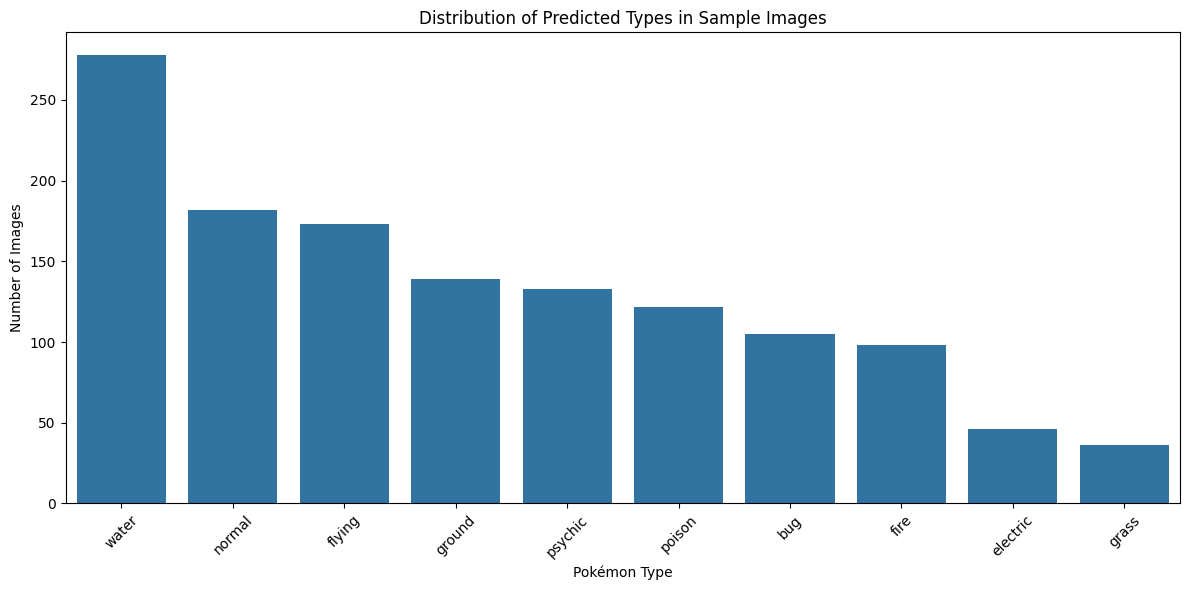

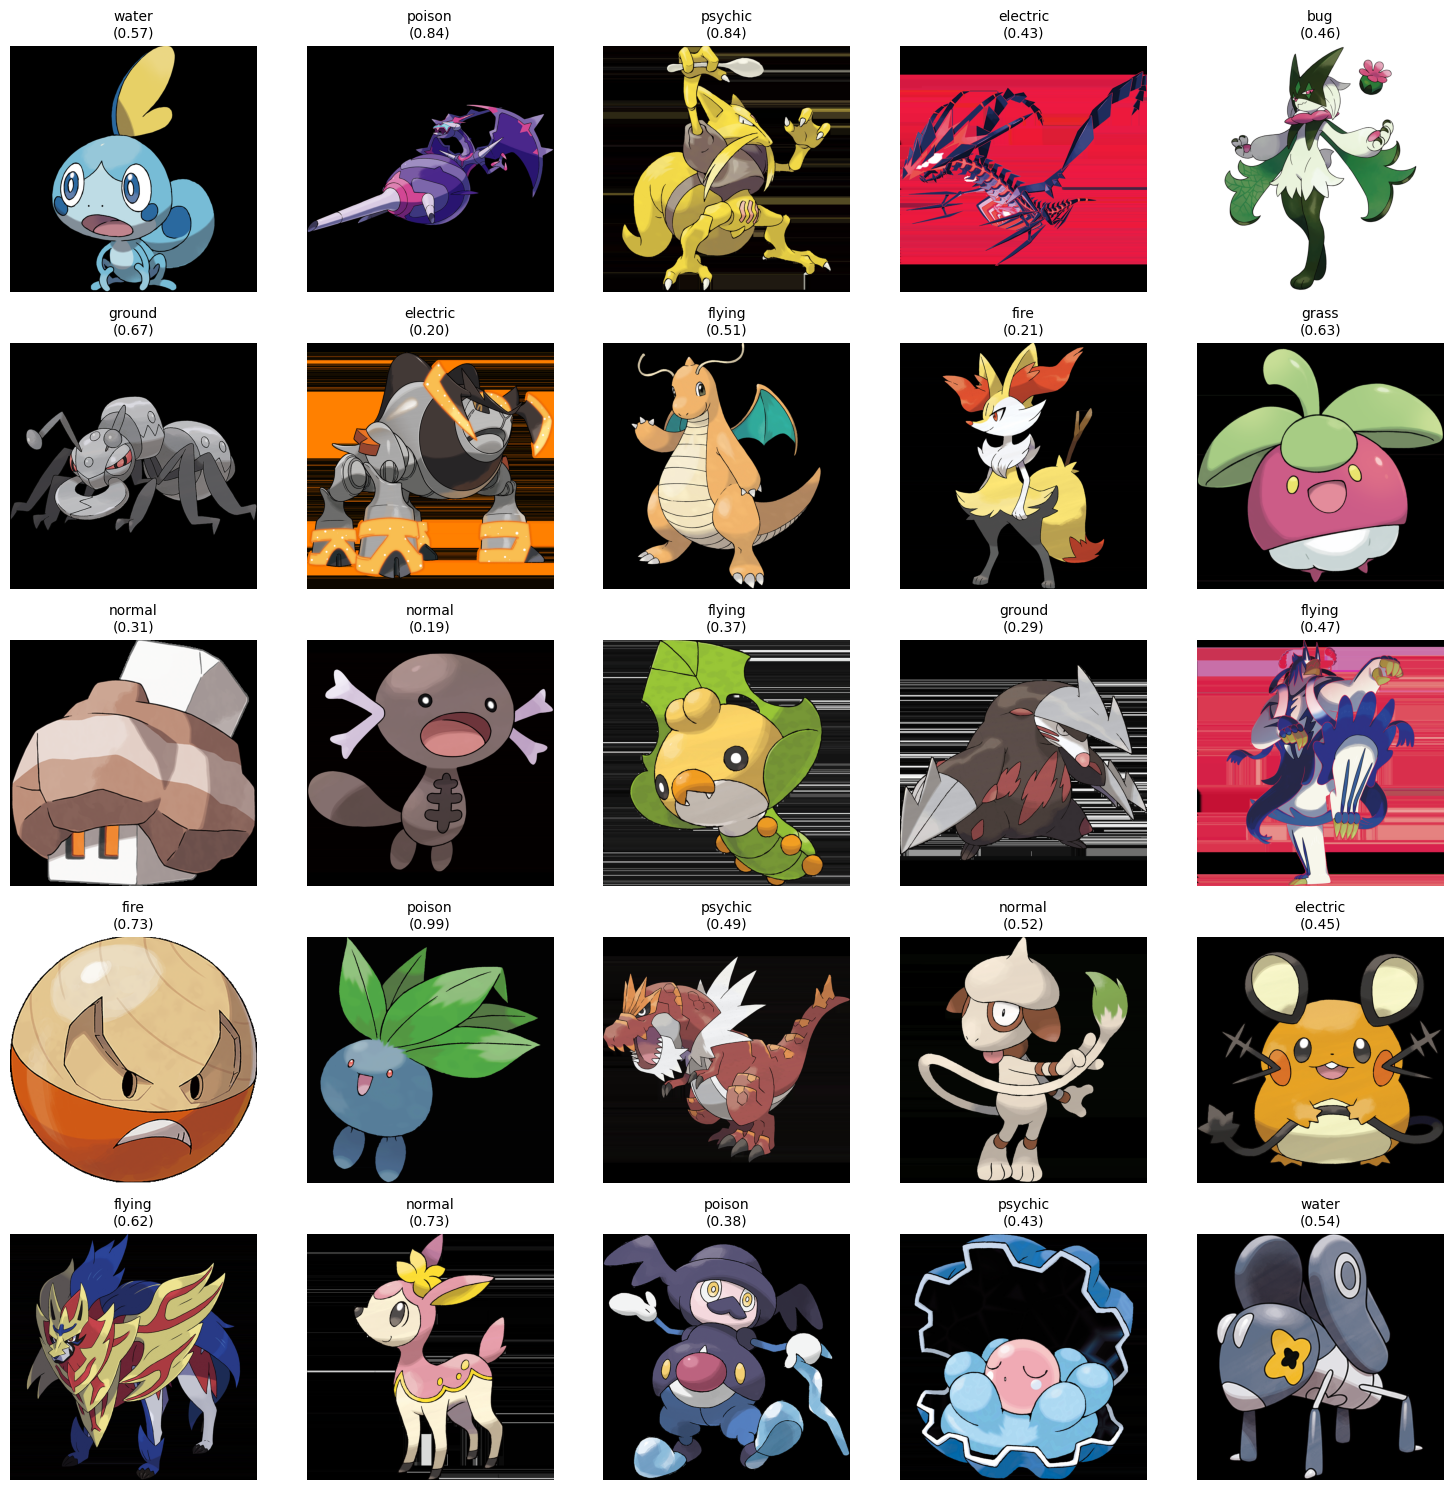

In [35]:
sample_folder = "sample"
sample_results = predict_sample_folder(model, mlb.classes_, sample_folder, output_dir)

## Conclusion

High precision (82.9% macro avg) with lower recall (54.4%) across all types

Type-specific performance varies significantly:
- Fire type is most successfully classified (F1=0.79)
- Electric has great precision (96.6%) but struggles with recall (43.2%)
- Ground type is pretty meh (F1=0.53)

Class distribution impact:
- Performance doesn't directly correlate with sample quantity
- Normal type (highest count at 223) achieves only moderate performance
- Grass type (lower count at 103) performs relatively well (F1=0.75)

Visual features likely influence recognition:
- Fire types with distinctive colors (orange and white and red) perform best
- Ground types show poorest results

The model correctly identifies Pokemon types ~60% of the time.


### Challenges:
1. Handling class imbalance
2. Multi-label classification complexity - we initially started with single type before broadening scope
3. Visual similarity between certain types (e.g., rock/ground, normal and literally everything)

### Future Research:
1. Experiment with different architectures and hyperparameters
2. Include more generations of Pokemon